# K-Nearest Neighbors (KNN)

Training a KNN classifier to predict the best crop from soil and weather conditions. We use a 60/20/20 train, validation and test split. The validation set helps us choose K, while the test set is kept for the final evaluation.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
os.makedirs("../outputs", exist_ok=True)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


## Load and Split the Dataset

All four models use the same split so that the final comparison is fair.

In [2]:
df = pd.read_csv("../Dataset/Crop_recommendation_dataset.csv")
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
X = df[features]
y = df["label"]

# First keep 20% aside for the final test set.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 25% of the remaining 80% gives 20% of the full dataset for validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1320, 7)
Validation set: (440, 7)
Test set: (440, 7)


## Scale the Input Features

KNN uses distance to find nearby points, so features with large numbers can dominate the calculation. We fit the scaler only on the training data, then use the same scaler for validation and test data.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Choose the Best K

We test K values from 1 to 10 on the validation set. We then choose the K with the highest validation accuracy.

Best K: 3
Best validation accuracy: 0.9636


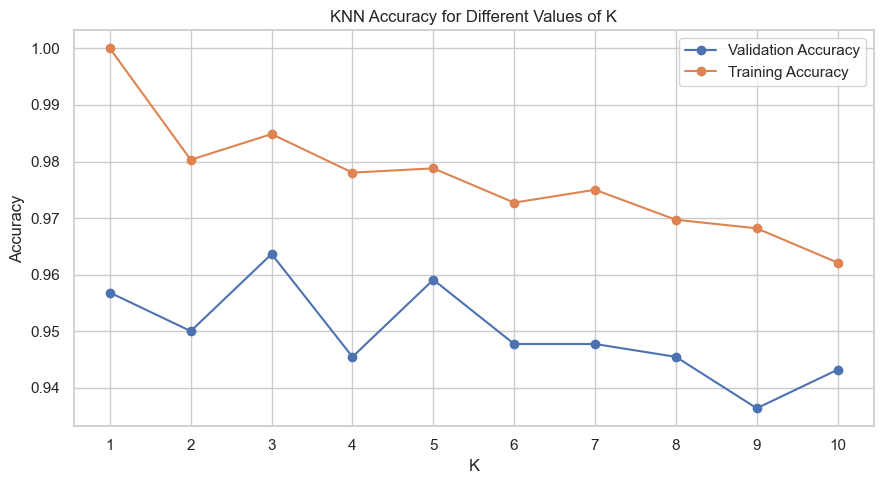

In [4]:
k_values = range(1, 11)
train_accuracies = []
val_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    val_accuracies.append(accuracy_score(y_val, model.predict(X_val_scaled)))

best_k = list(k_values)[val_accuracies.index(max(val_accuracies))]
print(f"Best K: {best_k}")
print(f"Best validation accuracy: {max(val_accuracies):.4f}")

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), val_accuracies, marker="o", label="Validation Accuracy")
plt.plot(list(k_values), train_accuracies, marker="o", label="Training Accuracy")
plt.title("KNN Accuracy for Different Values of K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.xticks(list(k_values))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../outputs/knn_k_selection.png", dpi=200, bbox_inches="tight")
plt.show()

## Train the Final KNN Model

After K is selected using validation data, we combine training and validation. Because KNN depends on feature scaling, a new scaler is fitted on the combined 80% and the untouched test set is transformed using that same scaler.


In [5]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train_final)
X_test_final_scaled = final_scaler.transform(X_test)

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_final_scaled, y_train_final)

print(f"Final KNN trained with K = {best_k}")
print("Final training set:", X_train_final.shape)
print("Final test set:", X_test.shape)


Final KNN trained with K = 3
Final training set: (1760, 7)
Final test set: (440, 7)


## Final Test Evaluation

The test set has not been used for choosing K. We use it now to measure the final performance.

In [6]:
y_pred = knn_model.predict(X_test_final_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("KNN Final Test Statistics")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


KNN Final Test Statistics
Accuracy:  0.9773
Precision: 0.9790
Recall:    0.9773
F1-score:  0.9771

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.91      1.00      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.95      0.95      0.95        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.85      0.92        20
    mungbean       1.00      1.00      1.00        20
   muskmelon 

## Confusion Matrix

The confusion matrix shows the crops that were predicted correctly and where the model made mistakes.

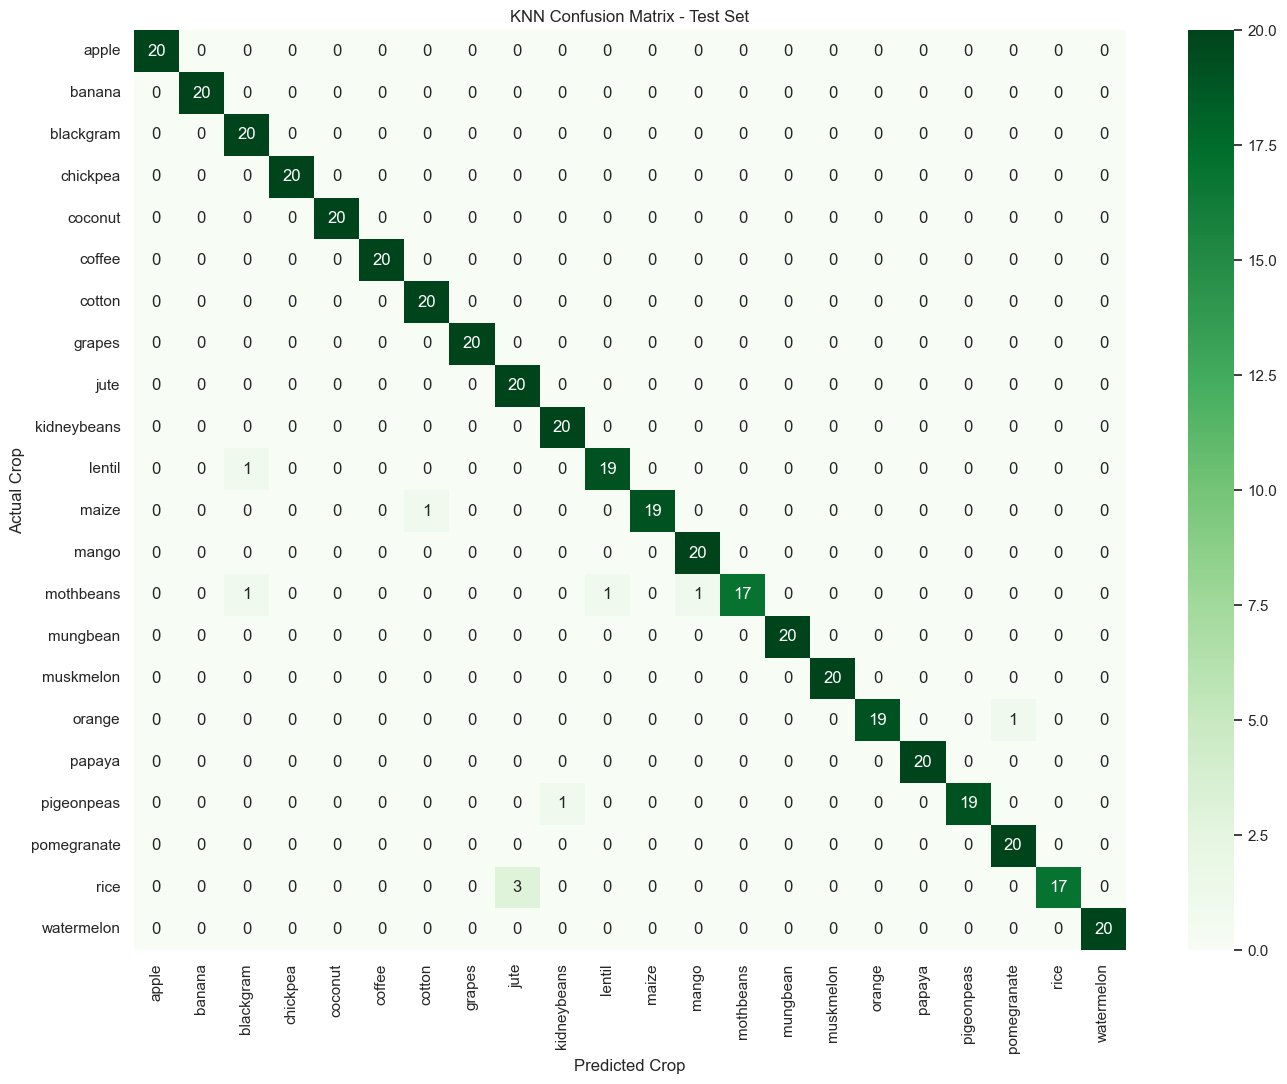

In [7]:
classes = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=classes, yticklabels=classes)
plt.title("KNN Confusion Matrix - Test Set")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/knn_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

## Cross-Validation Check

We also run 5-fold cross-validation on the original training data as a stability check. A Pipeline fits StandardScaler separately inside each fold, preventing preprocessing leakage between folds.


In [8]:
knn_cv_model = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=best_k))])
cv_scores = cross_val_score(knn_cv_model, X_train, y_train, cv=5, scoring="accuracy")
print("Cross-validation scores:", cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Cross-validation scores: [0.96212121 0.97727273 0.96969697 0.97727273 0.97727273]
Mean CV accuracy: 0.9727 (+/- 0.0061)


c:\Users\ginag\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\ginag\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\ginag\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\ginag\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\ginag\AppData\Local\Programs\Python\Python313\Lib\site-pack

## Findings

KNN uses the validation set to select K without using the test set. After K is fixed, training and validation are combined and the final KNN is retrained on 80% of the dataset with a newly fitted scaler. Five-fold cross-validation on the training data provides an additional stability check. The untouched 20% test set is used only for final evaluation.
